In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pickle

from scipy.interpolate import interp1d

from matplotlib.ticker import ScalarFormatter

current_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/notebooks'

# Build the absolute path to ../functions
functions_path = os.path.abspath(os.path.join(current_dir, '../functions'))

# Add it to sys.path
sys.path.append(functions_path)

import parse_data 
import cigar as cig

from tqdm import tqdm


In [92]:
colors = ['royalblue', 'crimson', 'black', 'green', 'darkorange', 'brown', 'coral', 'indigo', 'magenta', 'blue']


In [93]:


font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size
     


##  Data reading

In [94]:
# gas = 'Xe'
gas = 'Ar'

In [95]:
if gas == 'Ar':
    # runs    = {8.5:f'Run{120}'
    #            ,7.5:f'Run{123}'
    #            ,6.5:f'Run{127}'
    #            ,5.5:f'Run{132}'
    #            }

    runs    = {8.5:f'Run{171}' 
               ,7.5:f'Run{173}'
               ,6.5:f'Run{175}'
               ,5.5:f'Run{177}'
               ,4.5:f'Run{179}'
               ,3.5:f'Run{181}'
               ,2.5:f'Run{183}'
               ,1.5:f'Run{185}'
               }

In [96]:
# bars = 5.5
bars = list(runs.keys())[-1]


In [97]:
spectrum_dir    = f"/home/marian/CIGAR_ANALYSIS/CIGAR/data/spectrums"

In [98]:

with open(f'{spectrum_dir}/spectrum_data_{runs[bars]}.pkl', 'rb') as f:
    spectrum_data = pickle.load(f)


In [99]:
spectrum_data.keys()

dict_keys(['bins', 'spectrum_charge', 'spectrum_counts', 'spectrum_counts_err', 'fit_params', 'fit_covariance', 'x_fit', 'y_fit', 'run', 'params'])

In [100]:

# Access everything
bins                = spectrum_data['bins']
spectrum_charge     = spectrum_data['spectrum_charge']
spectrum_counts     = spectrum_data['spectrum_counts']
spectrum_counts_err = spectrum_data['spectrum_counts_err']
params              = spectrum_data['params']
popt                = spectrum_data['fit_params']
x_fit               = spectrum_data['x_fit']
y_fit               = spectrum_data['y_fit']
# etc...

##  Spectrum check

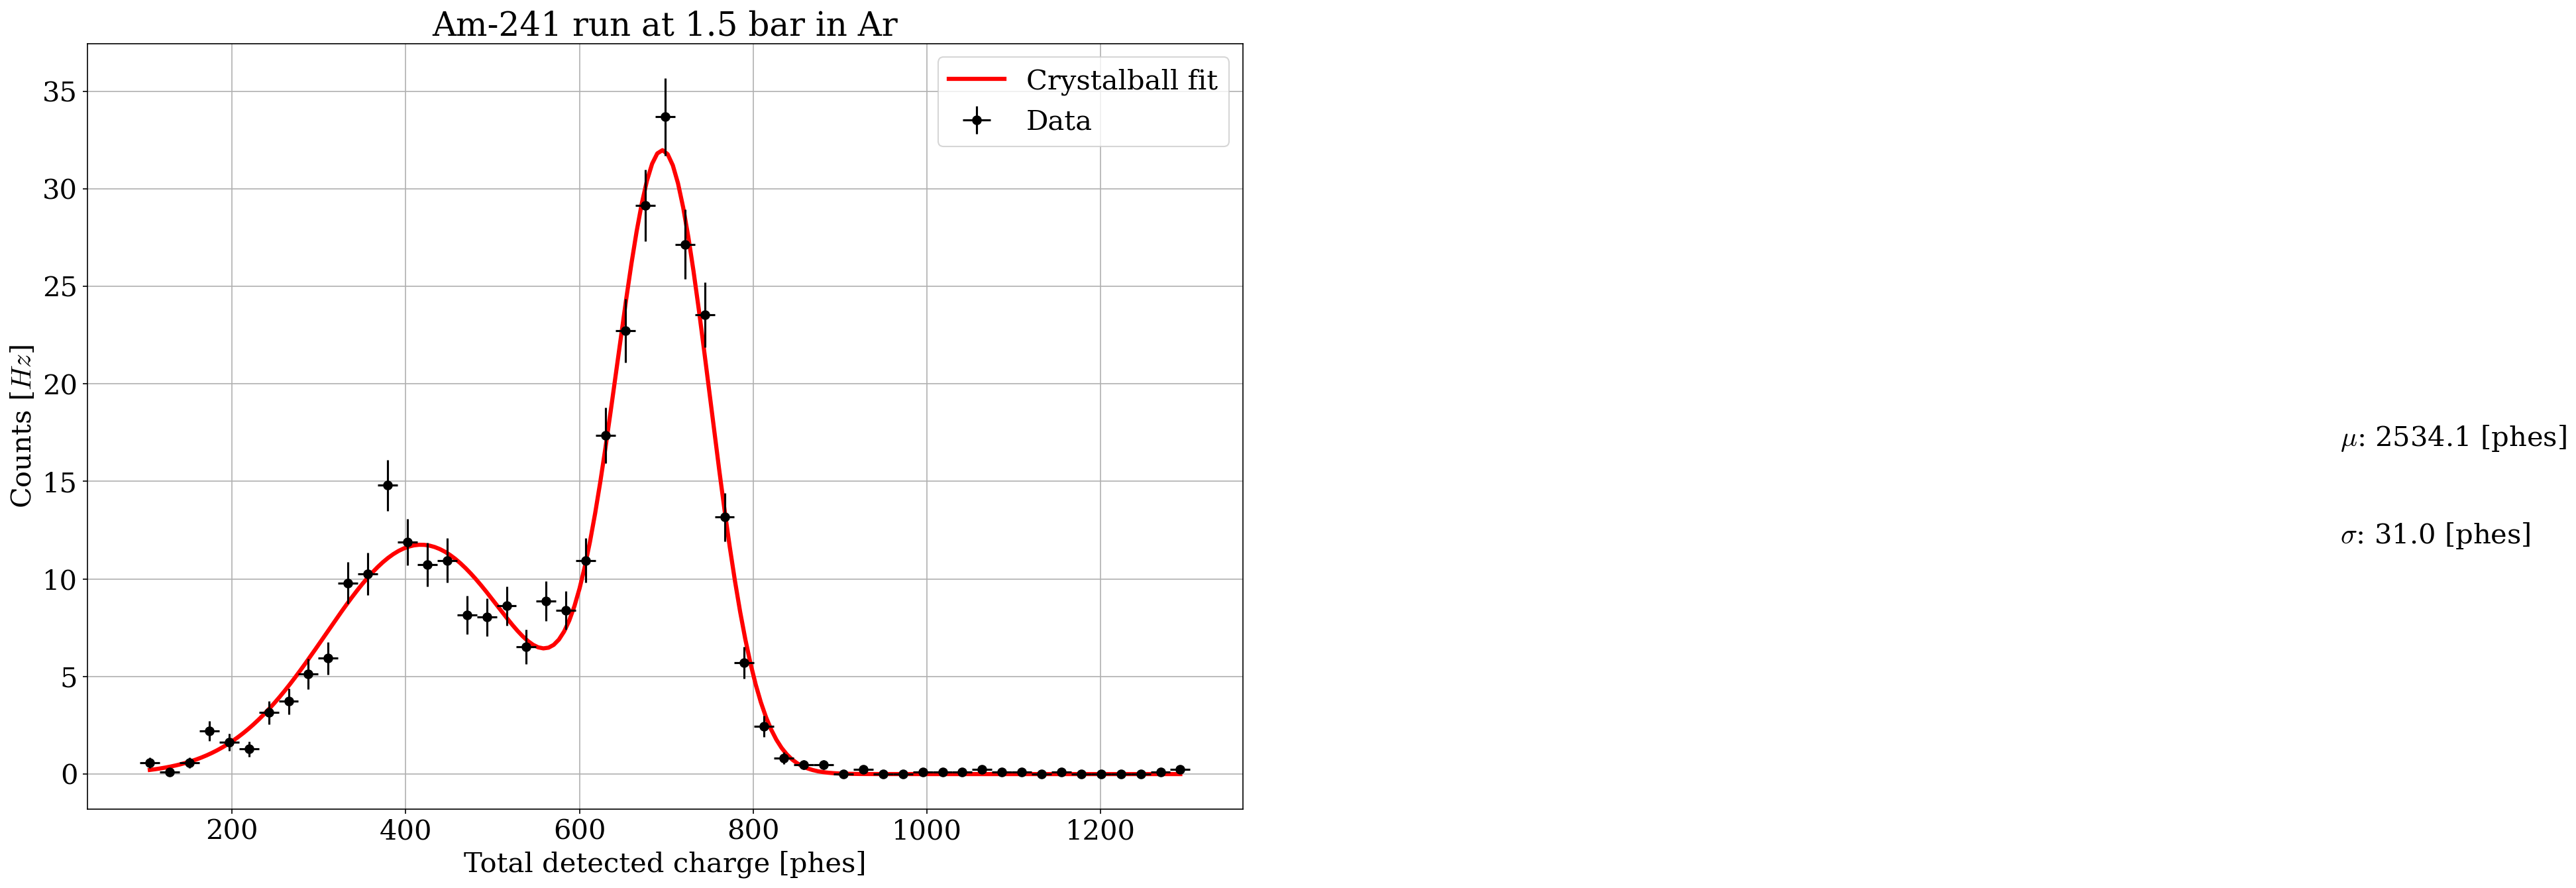

In [101]:
from scipy.stats import crystalball
def crystal_ball_pdf(x, A, beta, m, loc, scale):
    return A * crystalball.pdf(x, beta, m, loc=loc, scale=scale)


fig, ax = plt.subplots(1, 1, figsize=(15, 10), dpi=150)

ax.set_title(f'Am-241 run at {bars} bar in {gas}')


ax.errorbar(x = spectrum_charge
            ,y = spectrum_counts
            ,yerr = spectrum_counts_err
            ,xerr=(bins[1]-bins[0])/2
            ,fmt='o'
            ,color='k' 
            ,label = 'Data'
            ,zorder=5
            )


ax.plot(x_fit, y_fit, '-r', lw=3, label = f'Crystalball fit')

ax.set_ylabel(fr'Counts [$Hz$]')
ax.grid(True)
# ax.set_yscale('log')
ax.legend()
ax.text(popt[3] + 3*popt[4], spectrum_counts.max()*0.5, fr"$\mu$: {popt[3]:.1f} [phes]")
ax.text(popt[3] + 3*popt[4], spectrum_counts.max()*0.5 - 5, fr"$\sigma$: {popt[4]:.1f} [phes]")


if params['pes']:
    ax.set_xlabel(r'Total detected charge [phes]')
else:
    ax.set_xlabel(r'Total detected charge [V $\cdot$ s]')


##  Efficiency calculation 

In [106]:
def CalculateEfficiency(gas, pressure, run, poisson_aprox = False):
    
    if gas == 'Ar':
        reference_plot = {2.004: 1.075e5,
                        2.512: 1.088e5,
                        2.985: 1.122e5,
                        3.493: 1.180e5,
                        4.000: 1.233e5,
                        4.507: 1.285e5,
                        4.997: 1.325e5,
                        6.011: 1.526e5,
                        6.974: 1.727e5,
                        8.004: 1.903e5,
                        8.967: 2.072e5,
                        9.965: 2.183e5}


    # Extract X and Y values and sort them
    x = np.array(sorted(reference_plot.keys()))
    y = np.array([reference_plot[k] for k in sorted(reference_plot.keys())])

    # Create an interpolation function (linear by default)
    reference_func = interp1d(x, y, kind='linear', fill_value="extrapolate")

    # Light corrections (teflon + source)
    detectable_ratio = {1.5:0.709
                        ,2.5:0.630
                        ,3.5:0.5299
                        ,4.5:0.5334
                        ,5.5:0.532
                        ,6.5:0.518
                        ,7.5:0.513
                        ,8.5:0.507}

        
    with open(f'{spectrum_dir}/spectrum_data_{run}.pkl', 'rb') as f:
        spectrum_data = pickle.load(f)

        popt                = spectrum_data['fit_params']
        pcov                = spectrum_data['fit_covariance']

        num_cb = len(popt) // 5  # recover number of crystal balls from popt
        locs     = popt[3*num_cb : 4*num_cb]       # all loc parameters
        locs_var = np.diag(pcov)[3*num_cb : 4*num_cb]  # their variances

        # Take the highest mu (rightmost peak)
        best_idx = np.argmax(locs)
        mu       = locs[best_idx]
        mu_err   = np.sqrt(locs_var[best_idx])

        produced_photons    = reference_func(pressure)
        corrections         = detectable_ratio[pressure]
        detectable_photons  = produced_photons*corrections

        detected_pes        = mu
        detected_pes_err    = mu_err
        
        k       = detected_pes
        N       = detectable_photons
        # N_err   = np.sqrt(photons_plate_err**2 + photons_teflon_err**2)
        N_err   = np.sqrt(N)

        eff = k/N
        if poisson_aprox:
            k_err       = np.sqrt(k)
            eff_error   = (k/N)*np.sqrt((k_err/k)**2 + (N_err/N)**2)
        else:
            # Binomial aprox
            eff_error = np.sqrt(k*(1 - k/N))*(1/N)
    

    return eff, eff_error, detected_pes, detected_pes_err, detectable_photons

##  Efficiency

1.5: 0.92%


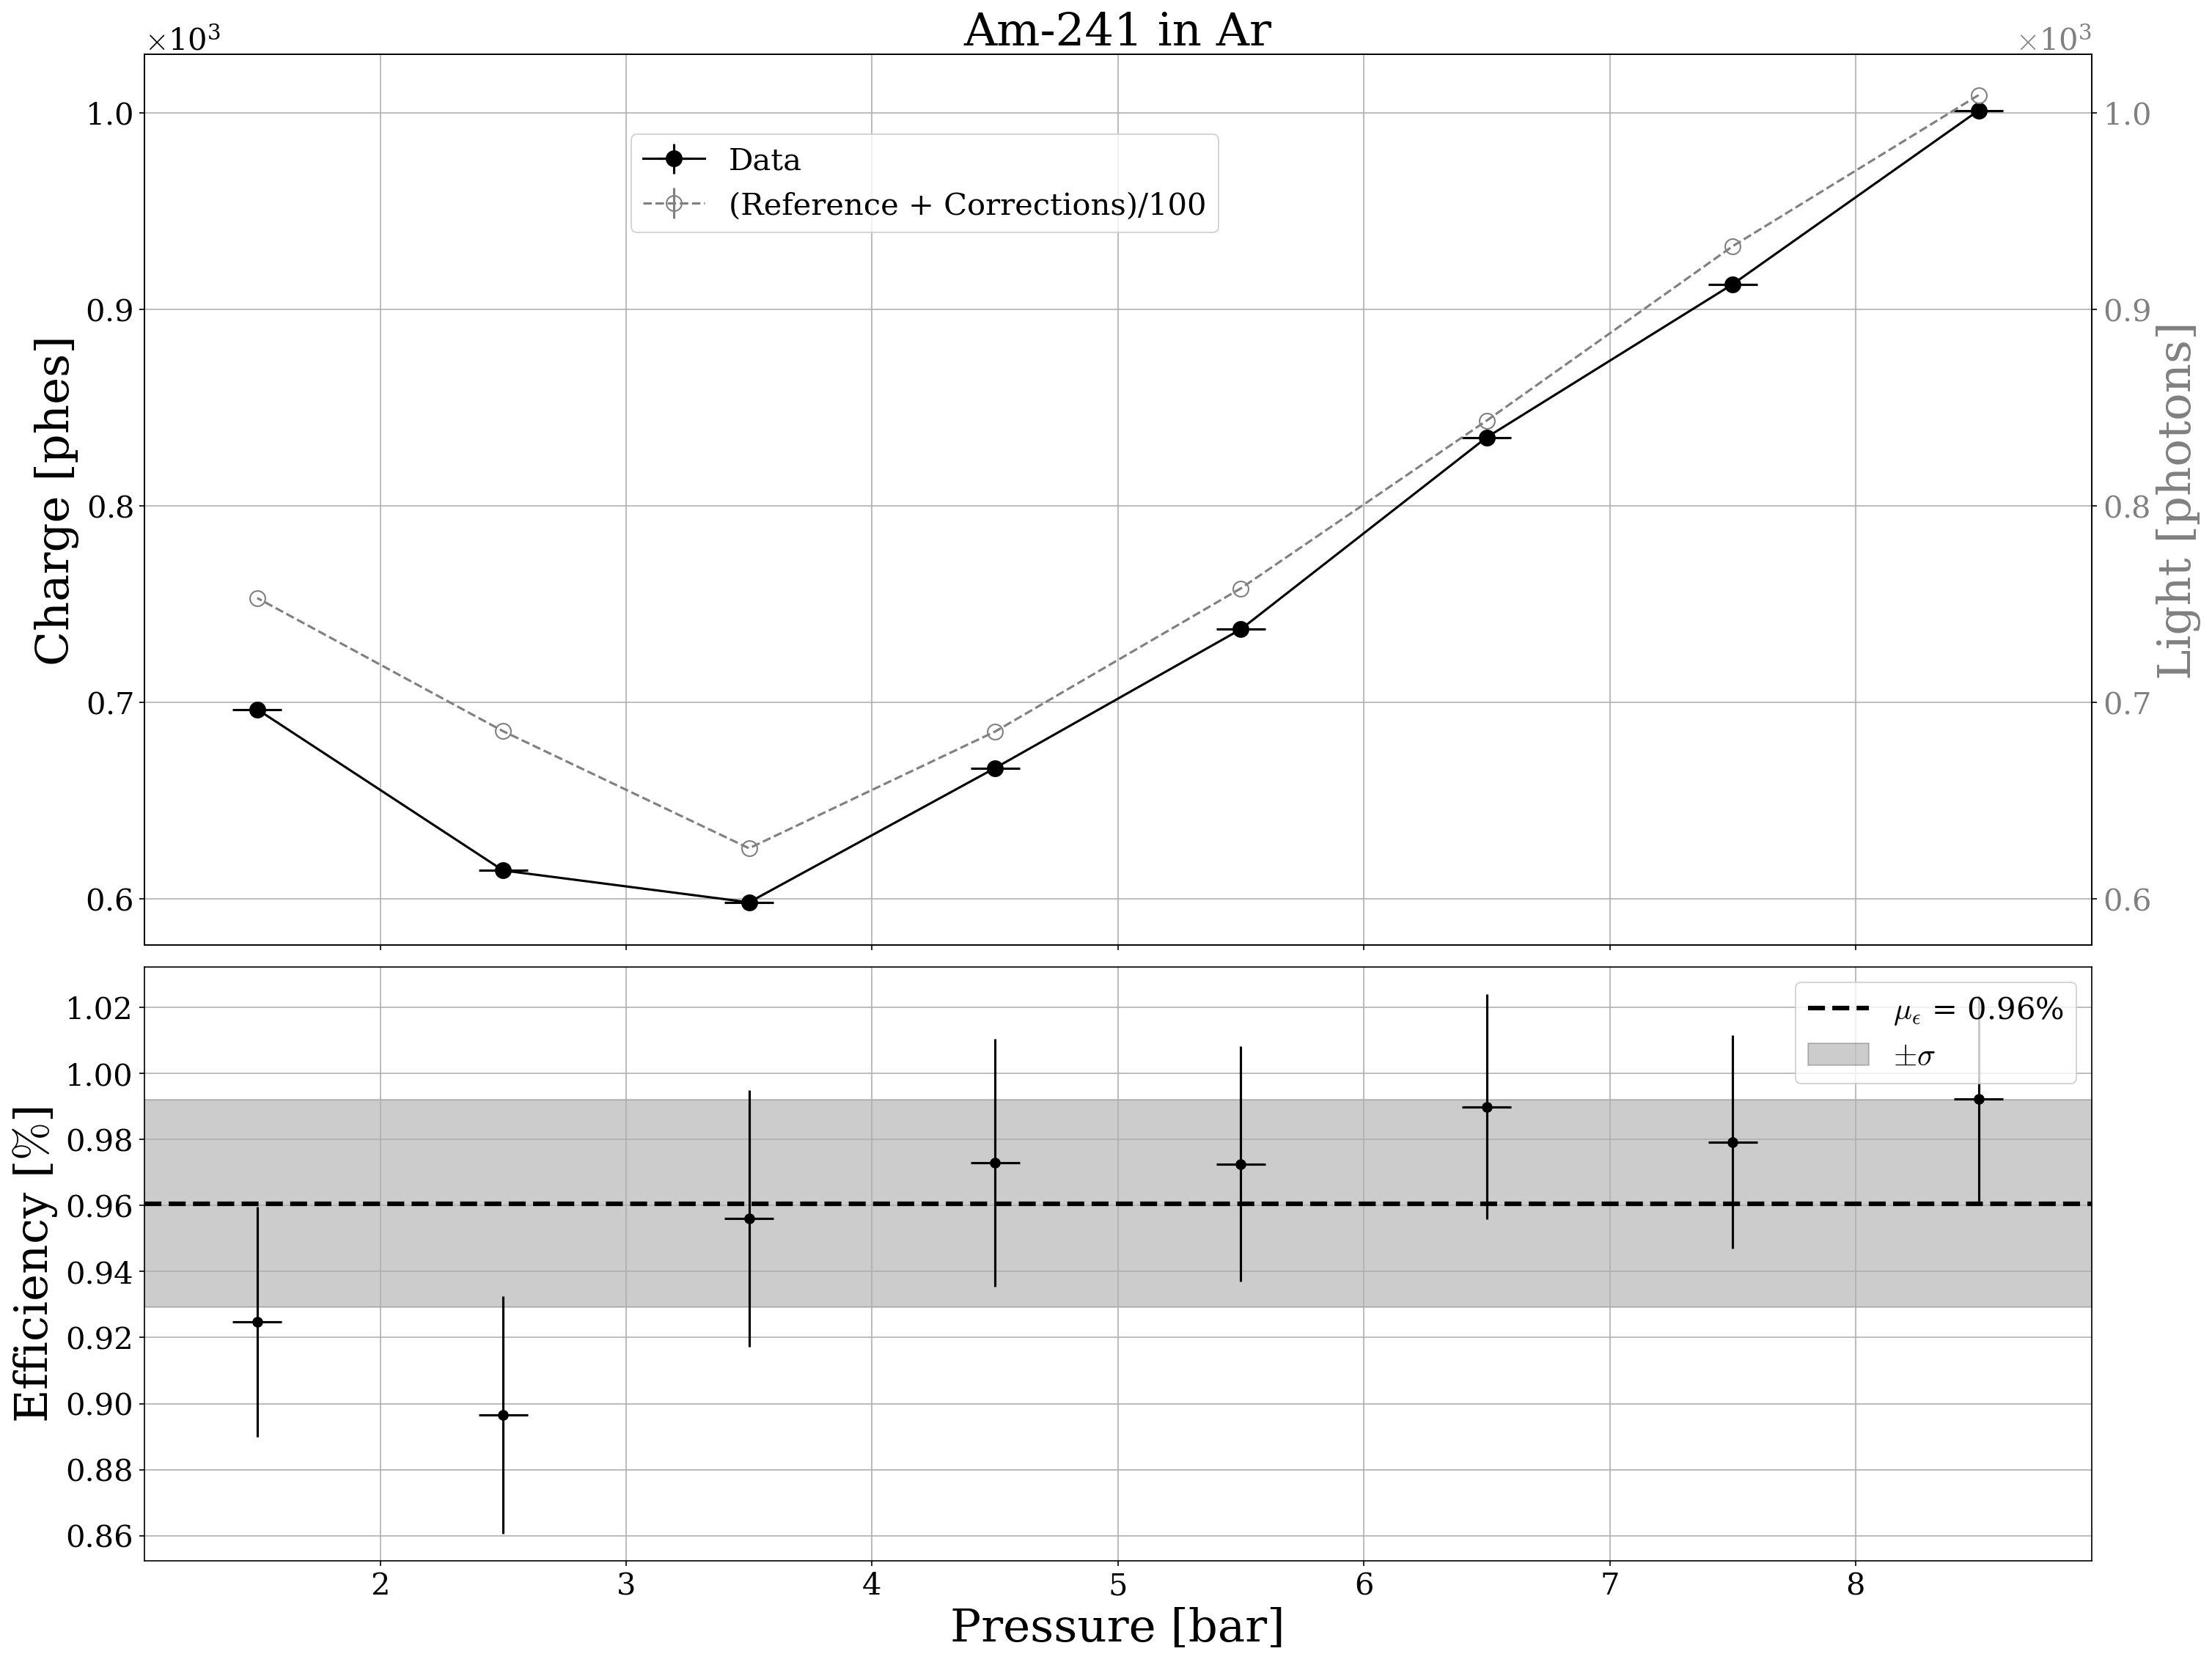

In [107]:
fig, axs = plt.subplots(2, 1
                        ,figsize=(20, 15)
                        ,dpi=150
                        ,sharex=True
                        ,gridspec_kw={'height_ratios': [3, 2]}  # top subplot twice as tall
                        ,constrained_layout=True
                        )

axs[0].set_title(f"Am-241 in {gas}", fontsize = 1.5*font_size)

efficiency              = []
efficiency_error        = []
detected_photons        = []
detected_photons_error  = []
detectable_ph           = []
for pressure, run in runs.items():
    
    eff, eff_error, detected_pes, detected_pes_err, detectable_photons = CalculateEfficiency(gas, pressure, run, poisson_aprox = False)

    efficiency.append(eff)
    efficiency_error.append(eff_error)
    detected_photons.append(detected_pes)
    detected_photons_error.append(detected_pes_err)
    detectable_ph.append(detectable_photons)

pressures = np.array(list(runs.keys()))
detectable_ph = np.array(detectable_ph)

# PLOT 1: Detected and detectable photons
ax = axs[0]
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

# Plot BOTH datasets on the SAME axis
ax.errorbar(x = pressures
            ,y = detected_photons
            ,yerr = detected_photons_error
            ,xerr=0.1
            ,fmt='-o'
            ,color='k' 
            ,markerfacecolor='k'
            ,markeredgecolor='k'
            ,markersize=10
            ,zorder=5
            ,label='Data'
            )

ax.errorbar(x = pressures
            ,y = detectable_ph/100
            ,yerr = 0
            ,fmt='--o'
            ,color='grey' 
            ,markerfacecolor='none'
            ,markeredgecolor='grey'
            ,markersize=10
            ,zorder=5
            ,label='(Reference + Corrections)/100'
            )

# Create a dummy second y-axis that mirrors the first
ax2 = ax.twinx()

# First, link the axes so they stay synchronized
ax2.set_ylim(ax.get_ylim())

# Share the y-axis with ax (this is the key!)
ax2.get_shared_y_axes().join(ax, ax2)

# Now just set the appearance
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax2.tick_params(axis='y', labelcolor='grey')
ax2.set_ylabel('Light [photons]', color='grey', fontsize = 1.5*font_size)

ax.legend(loc = (0.25, 0.8))
ax.set_ylabel('Charge [phes]', fontsize = 1.5*font_size)
ax.grid(True)

# PLOT 2: Efficiency
ax = axs[1]

efficiency = np.array(efficiency)*100
efficiency_error = np.array(efficiency_error)*100

ax.errorbar(x = pressures
            ,y = efficiency
            ,yerr = efficiency_error
            ,xerr=0.1
            ,fmt='o'
            ,color='k' 
            ,zorder=5
            # ,label='LCE'
            )


mean_efficiency = efficiency.mean()
std_efficiency = efficiency.std()

ax.axhline(mean_efficiency, linestyle="--", color='k', linewidth=3, label=fr'$\mu_{{\epsilon}}$ = {mean_efficiency:.2f}%')

xmin, xmax = ax.get_xlim()
ax.fill_between([xmin, xmax]
                ,mean_efficiency-std_efficiency
                ,mean_efficiency+std_efficiency 
                ,color='k' 
                ,alpha=0.2  # Transparency (0=fully transparent, 1=opaque)
                ,zorder=1 # Behind the data points
                ,label=r'$\pm \sigma$'
                )  
ax.set_xlim(xmin, xmax)
ax.legend()
ax.grid(True)

ax.set_ylabel(r'Efficiency [$\%$]', fontsize = 1.5*font_size)
ax.set_xlabel('Pressure [bar]', fontsize = 1.5*font_size)


print(f'{pressure}: {eff*100:.2f}%')

In [104]:
ax.get_xlim()

(1.04, 8.959999999999999)

In [105]:
list(runs.keys())

[8.5, 7.5, 6.5, 5.5, 4.5, 3.5, 2.5, 1.5]